In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect
import torch.autograd.profiler as profiler
from sklearn.model_selection import KFold
device = torch.device("cpu")

In [2]:

if __name__ == '__main__':

    # Hyperparameters
    # data_str = "ghq_b_sum"
    # data_str = "ghq_sum"
    data_str = "simulation"
    batch_size = 1           # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 16             # number of heads
    ncum = 2                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 100
    target_sample_size = 7
    nrepp = 10
    
    # Set the random seed for reproducibility
    torch.manual_seed(42)
    
    n = 200
    p = 10
    maxlen = 10
    # Create Dataset and DataLoader
    train_dataset = SimulatedDataset(n, p, maxlen=maxlen, device = device).data
    predindex = 2
    


    n = len(train_dataset)
    p = train_dataset[0].shape[1]
    print("Sample size: ", len(train_dataset), "\n")
    



    mask = create_custom_mask(maxlen, device)
    distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
    pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)


    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
    
    model = MiniTransformer(p, nheads, dk, dv, ncum, mask, pairwise_distance_matrix, distance_to_end_matrix,  device)

    model.apply(init_weights_recursive)
    model.to(device)

    # model = torch.compile(model)
    # Start the timer
    start_time = time.time()

    # Define optimizer
    # optimizer = optim.Adam(model.parameters(), lr= learning_rate, weight_decay=lambda_l2)
    optimizer = optim.Adam(model.parameters(), lr= learning_rate)
    
    print("Number of Parameters", transformerFunctions.count_parameters(model))
    
    run_path = transformerFunctions.train_mini_transformer(model, dataloader, optimizer, lambda_l2, EPOCHS, device)


    # End the timer
    end_time = time.time()

    # Calculate and print the execution time
    execution_time = end_time - start_time 
    print(f"Execution time: {execution_time:.6f} seconds")




Sample size:  200 

Number of Parameters 592
EPOCH 1:
avg_loss: 17.42484
EPOCH 2:
avg_loss: 9.52035
EPOCH 3:
avg_loss: 9.32636
EPOCH 4:
avg_loss: 9.14227
EPOCH 5:
avg_loss: 9.00269
EPOCH 6:
avg_loss: 8.88820
EPOCH 7:
avg_loss: 8.78728
EPOCH 8:
avg_loss: 8.69708
EPOCH 9:
avg_loss: 8.61821
EPOCH 10:
avg_loss: 8.54514
EPOCH 11:
avg_loss: 8.48122
EPOCH 12:
avg_loss: 8.42639
EPOCH 13:
avg_loss: 8.38287
EPOCH 14:
avg_loss: 8.35097
EPOCH 15:
avg_loss: 8.30505
EPOCH 16:
avg_loss: 8.27413
EPOCH 17:
avg_loss: 8.25207
EPOCH 18:
avg_loss: 8.22771
EPOCH 19:
avg_loss: 8.20416
EPOCH 20:
avg_loss: 8.18475
EPOCH 21:
avg_loss: 8.16745
EPOCH 22:
avg_loss: 8.14723
EPOCH 23:
avg_loss: 8.13502
EPOCH 24:
avg_loss: 8.11274
EPOCH 25:
avg_loss: 8.09553
EPOCH 26:
avg_loss: 8.08093
EPOCH 27:
avg_loss: 8.06175
EPOCH 28:
avg_loss: 8.04224
EPOCH 29:
avg_loss: 8.02386
EPOCH 30:
avg_loss: 8.00548
EPOCH 31:
avg_loss: 7.98372
EPOCH 32:
avg_loss: 7.96531
EPOCH 33:
avg_loss: 7.95007
EPOCH 34:
avg_loss: 7.93555
EPOCH 35:
a

In [3]:
avepval, stdpval, context, targetall = statistical_testing(model, train_dataset, p, predindex, nrepp, target_sample_size)

Repetition 1/10
Repetition 2/10
Repetition 3/10
Repetition 4/10
Repetition 5/10
Repetition 6/10
Repetition 7/10
Repetition 8/10
Repetition 9/10
Repetition 10/10


In [4]:
print_p_values(avepval, stdpval)

Variable 1: 0.003182 ± 0.000000
Variable 2: 0.005111 ± 0.000000
Variable 3: 0.000016 ± 0.000000
Variable 4: 0.509355 ± 0.000000
Variable 5: 0.653755 ± 0.000000
Variable 6: 0.291606 ± 0.000000
Variable 7: 0.788288 ± 0.000000
Variable 8: 0.870599 ± 0.000000
Variable 9: 0.456303 ± 0.000000
Variable 10: 0.516305 ± 0.000000


In [5]:
context_predindex_pair_effect = get_context_predindex_pair_effect(model, p, context, targetall, nrepp)    

Repetition 1/10
Repetition 2/10
Repetition 3/10
Repetition 4/10
Repetition 5/10
Repetition 6/10
Repetition 7/10
Repetition 8/10
Repetition 9/10
Repetition 10/10


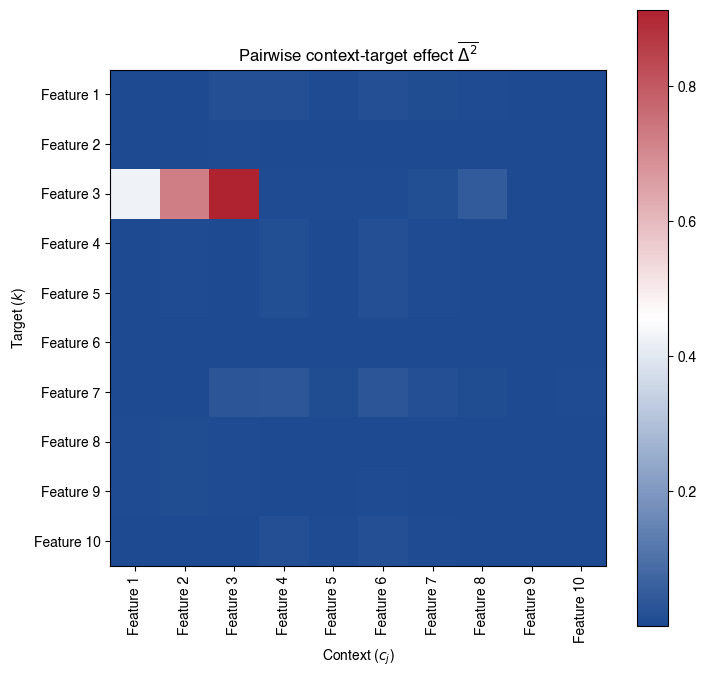

In [6]:
plot_context_predindex_pair_effect(context_predindex_pair_effect, data_str, run_path)